   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 19.7 MB/s eta 0:00:00
Mounted at /content/drive
Save folder: /content/drive/MyDrive
✅ Shape: (731, 6)


,sales_date,units_sold,sales_amount,lag_1,lag_7,rolling_7
0,2023-05-27,12,0.041708,NaN,NaN,NaN
1,2023-05-28,10,0.051619,0.041708,NaN,NaN
2,2023-05-29,18,0.087004,0.051619,NaN,NaN
3,2023-05-30,11,0.046202,0.087004,NaN,NaN
4,2023-05-31,10,0.069156,0.046202,NaN,NaN


Target column: sales_amount
After feature creation: (701, 9)


,sales_date,units_sold,sales_amount,lag_1,lag_7,rolling_7,lag_14,roll_7,roll_30
0,2023-06-26,15,1.083409,0.091716,0.066620,0.219123,0.082976,0.073867,0.206340
1,2023-06-27,16,0.077917,1.083409,0.083223,0.218365,0.074167,0.219123,0.241064
2,2023-06-28,15,2.041021,0.077917,0.082248,0.498190,1.049687,0.218365,0.241940
3,2023-06-29,13,0.049259,2.041021,0.079093,0.493928,0.101380,0.498190,0.307074
4,2023-06-30,18,0.092174,0.049259,0.052272,0.499628,0.037188,0.493928,0.307176


Train shape: (673, 9) Test shape: (28, 9)
Naive (lag-7) MAE: 0.13
Naive (lag-7) sMAPE: 44.84%


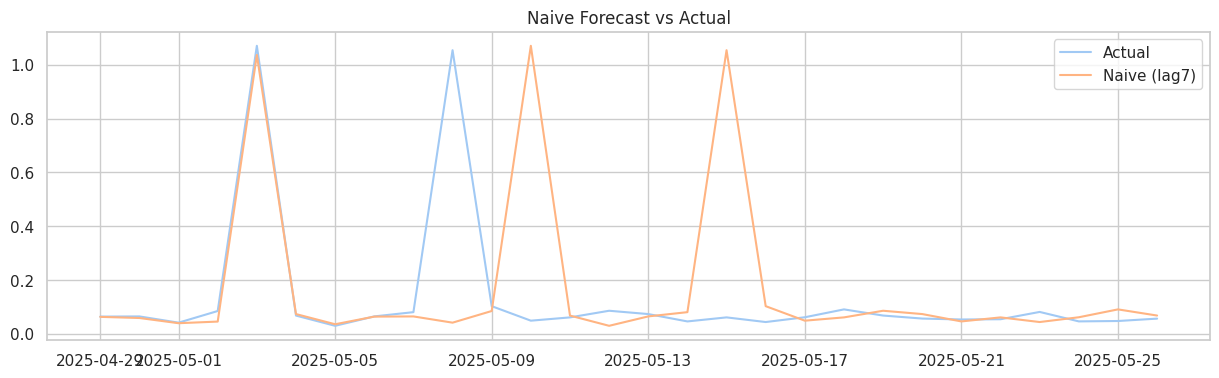

LightGBM MAE: 0.2361, sMAPE: 175.37%


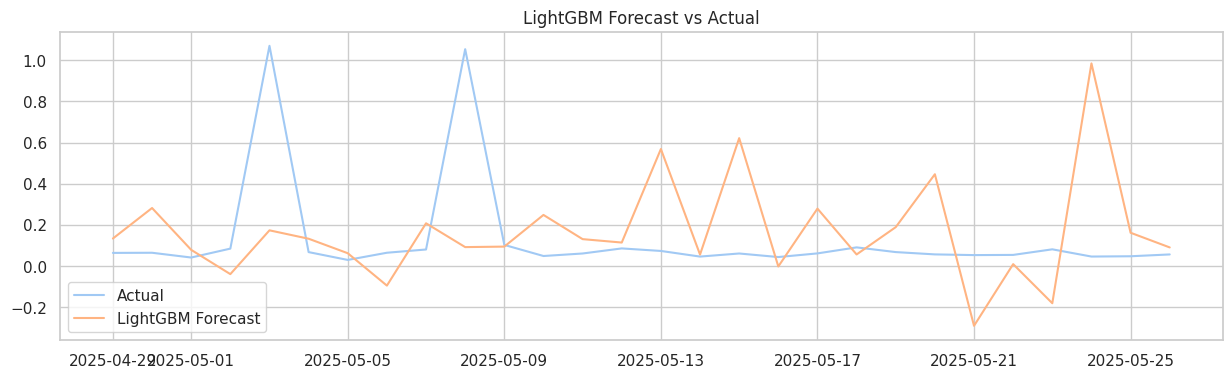

Backtest MAEs (expanding windows): [0.31314520398827217, 0.20497810808005307, 0.37004760788336916, 0.28963527847983833, 0.2188342209553471, 0.3224856393426273, 0.3388473342628352, 0.3416052157706256, 0.3358004055369115, 0.29762066838633977, 0.23962645309131517, 0.29386273414461467, 0.2836698546247561, 0.21453836651826083, 0.26791322139828205, 0.17529136188466615, 0.17184808190535922, 0.23099451339874216]
Saved model to: /content/drive/MyDrive/lgb_model_v1.joblib
Saved forecast CSV (ready for pgAdmin) to: /content/drive/MyDrive/sales_forecast.csv


,model,mae,smape
0,naive_lag7,0.125676,44.842628
1,lightgbm,0.236107,175.372659


Notebook 5 complete ✅ — Modeling & forecasting finished!


In [ ]:
# =========================
# Part 1 — Setup
# =========================
!pip install --quiet lightgbm joblib psycopg2-binary

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error
from joblib import dump
sns.set(style="whitegrid", palette="pastel")

# =========================
# Part 2 — Mount Google Drive
# =========================
try:
    from google.colab import drive
    drive.mount('/content/drive', force_remount=False)
    DRIVE_BASE = '/content/drive/MyDrive'
except:
    DRIVE_BASE = '/content'

os.makedirs(DRIVE_BASE, exist_ok=True)
print("Save folder:", DRIVE_BASE)

# =========================
# Part 3 — Load daily aggregated dataset
# =========================
daily_path = os.path.join(DRIVE_BASE, 'daily_sales_for_modeling.csv')
daily = pd.read_csv(daily_path, parse_dates=['sales_date'])
daily = daily.sort_values('sales_date').reset_index(drop=True)
print("Shape:", daily.shape)
display(daily.head())

target_col = 'sales_amount' if 'sales_amount' in daily.columns else 'units_sold'
print("Target column:", target_col)

# =========================
# Part 4 — Feature engineering (lags & rolling)
# =========================
daily['lag_1'] = daily[target_col].shift(1)
daily['lag_7'] = daily[target_col].shift(7)
daily['lag_14'] = daily[target_col].shift(14)
daily['roll_7'] = daily[target_col].shift(1).rolling(7).mean()
daily['roll_30'] = daily[target_col].shift(1).rolling(30).mean()

daily_feat = daily.dropna().reset_index(drop=True)
print("After feature creation:", daily_feat.shape)
display(daily_feat.head())

# =========================
# Part 5 — Train/Test split
# =========================
horizon = 28
train = daily_feat[:-horizon]
test = daily_feat[-horizon:]
print("Train shape:", train.shape, "Test shape:", test.shape)

features = ['lag_1','lag_7','lag_14','roll_7','roll_30']
X_train, y_train = train[features], train[target_col]
X_test, y_test = test[features], test[target_col]

# =========================
# Part 6 — Baseline naive forecast
# =========================
y_predict_naive = X_test['lag_7'].values
mae_naive = mean_absolute_error(y_test, y_predict_naive)
smape = lambda a,f: 100*np.mean(2*np.abs(f-a)/np.abs(a+f))

print(f"Naive (lag-7) MAE: {mae_naive:.2f}")
print(f"Naive (lag-7) sMAPE: {smape(y_test, y_predict_naive):.2f}%")

plt.figure(figsize=(15,4))
plt.plot(daily_feat['sales_date'][-horizon:], y_test.values, label='Actual')
plt.plot(daily_feat['sales_date'][-horizon:], y_predict_naive, label='Naive (lag7)')
plt.legend(); plt.title('Naive Forecast vs Actual')
plt.show()

# =========================
# Part 7 — LightGBM modeling
# =========================
import lightgbm as lgb
dtrain = lgb.Dataset(X_train, label=y_train)
params = {'objective':'regression','metric':'mae','learning_rate':0.05,'verbosity':-1}
model = lgb.train(params, dtrain, num_boost_round=1000, valid_sets=[dtrain])

y_predict = model.predict(X_test)
mae_lgb = mean_absolute_error(y_test, y_predict)
print(f"LightGBM MAE: {mae_lgb:.4f}, sMAPE: {smape(y_test, y_predict):.2f}%")

plt.figure(figsize=(15,4))
plt.plot(daily_feat['sales_date'][-horizon:], y_test.values, label='Actual')
plt.plot(daily_feat['sales_date'][-horizon:], y_predict, label='LightGBM Forecast')
plt.legend(); plt.title('LightGBM Forecast vs Actual')
plt.show()

# =========================
# Part 8 — Backtesting
# =========================
def expanding_backtest(df, features, target, initial_train_days=180, horizon=28, step=28):
    results = []
    start = 0
    while start + initial_train_days + horizon <= len(df):
        train = df.iloc[start:start+initial_train_days]
        test = df.iloc[start+initial_train_days:start+initial_train_days+horizon]
        model = lgb.LGBMRegressor(learning_rate=0.05)
        model.fit(train[features], train[target])
        preds = model.predict(test[features])
        results.append(mean_absolute_error(test[target], preds))
        start += step
    return results

backtest_maes = expanding_backtest(daily_feat, features, target_col)
print("Backtest MAEs (expanding windows):", backtest_maes)

# =========================
# Part 9 — Save model & forecasts
# =========================
model_path = os.path.join(DRIVE_BASE, 'lgb_model_v1.joblib')
dump(model, model_path)
print("Saved model to:", model_path)

forecast_df = test[['sales_date']].copy()
forecast_df['actual'] = y_test.values
forecast_df['pred_lgb'] = y_predict
forecast_df['pred_naive'] = y_predict_naive

forecast_csv_path = os.path.join(DRIVE_BASE,'sales_forecast.csv')
forecast_df.to_csv(forecast_csv_path, index=False)
print("Saved forecast CSV (ready for pgAdmin) to:", forecast_csv_path)

# =========================
# Part 10 — Metrics summary
# =========================
metrics = {
    'model':['naive_lag7','lightgbm'],
    'mae':[mae_naive, mae_lgb],
    'smape':[smape(y_test,y_predict_naive), smape(y_test,y_predict)]
}
metrics_df = pd.DataFrame(metrics)
metrics_csv_path = os.path.join(DRIVE_BASE,'model_metrics.csv')
metrics_df.to_csv(metrics_csv_path, index=False)
display(metrics_df)

print("Notebook 5 complete — Modeling & forecasting finished!")
